#keras를 이용한 손글씨

In [25]:
#데이터 불러오기#0은 정답
import pandas as pd
train=pd.read_csv('../Data/train_20k.csv',header=None)
train.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
test=pd.read_csv('../Data/test_1k.csv',header=None)
test.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
#머신러닝 이미지 어쩌구
#결측치
train.info()#데이터 수 많으면 안보여줌

<class 'pandas.DataFrame'>
RangeIndex: 20001 entries, 0 to 20000
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 119.8 MB


In [28]:
train.isnull()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19999,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [29]:
train.isnull().sum()

0      0
1      0
2      0
3      0
4      0
      ..
780    0
781    0
782    0
783    0
784    0
Length: 785, dtype: int64

In [30]:
train.isnull().sum().sum()


np.int64(0)

In [31]:
#####################
#train의 0번(target)의 분포 확인
#label 종류 확인
train[0].unique()
train[0].value_counts()
###########

0
1    2281
7    2093
3    2076
9    2014
0    1994
6    1971
4    1945
2    1929
8    1922
5    1776
Name: count, dtype: int64

In [32]:
#target(0),feature(1~784)분리하고 정규화하기
# train_label=train.loc[:,0]
train_label=train.loc[:,train.columns==0]

In [33]:
train_label

,0
0,5
1,0
2,4
3,1
4,9
...,...
19996,5
19997,1
19998,4
19999,2


In [34]:
train_data=train.loc[:,train.columns!=0]
train_data=train_data/255


In [35]:
test_label=test.loc[:,test.columns==0]
test_data=test.loc[:,test.columns!=0]
test_data=test_data/255


#Deep Learning Model 만들기
-입력층:784??(28*28:갯수)
-은닉층:1284, activation= relu
-출력층:10(종류:0-9),activation=softmax
-compile:loss(sparse_categorical_crossentropy),optimizer=adam
-epoch:5,10,50,100

In [44]:

from tensorflow import keras
from tensorflow.keras.layers import Input

model=keras.Sequential()
model.add(Input(shape=(784,)))

model.add(keras.layers.Dense(1284, activation='relu'))
model.add(keras.layers.Dense(10,activation='softmax'))


In [ ]:
model.compile(
    optimizer='adam',#점프
    loss='sparse_categorical_crossentropy',#손실 함수   
    metrics=['accuracy']#<<<<<<<대괄호 조기종료 리스트
)#오차계산

In [ ]:
#훈련#자연어 처리 과적합? 청크?? -20개 묶어서 작업 미니 배치 일괄작업? 
#wait=>async pask??
#범위를 가지고 적당한 벙뮈
import numpy as np
hist=model.fit(np.array(train_data), np.array(train_label), epochs=50)


Epoch 1/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9166 - loss: 0.2795
Epoch 2/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9661 - loss: 0.1127
Epoch 3/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9804 - loss: 0.0648
Epoch 4/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9871 - loss: 0.0415
Epoch 5/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9918 - loss: 0.0275
Epoch 6/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9929 - loss: 0.0232
Epoch 7/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9940 - loss: 0.0180
Epoch 8/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9952 - loss: 0.0136
Epoch 9/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9949 - loss: 0.0151
Epoch 10/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9971 - loss: 0.0102
Epoch 11/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9956 - loss: 0.0163
Epoch 12/50
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step

In [47]:
#트레인 데이터로 평가#np.array생략가능
scores=model.evaluate(train_data,train_label)
print('loss=',scores[0])
print('accuracy=',scores[1])

626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 1.0000 - loss: 5.9488e-08
loss= 5.948841064196131e-08
accuracy= 1.0


In [48]:
#테스트 데이터로 평가#평가데이터
scores=model.evaluate(test_data,test_label)
print('loss=',scores[0])
print('accuracy=',scores[1])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9810 - loss: 0.1418 
loss= 0.14176075160503387
accuracy= 0.9810189604759216


In [49]:
#훈련 및 과정에 대한 history보기
hist.history.keys()#딕셔너리 시각화

dict_keys(['accuracy', 'loss'])

#손실 곡선

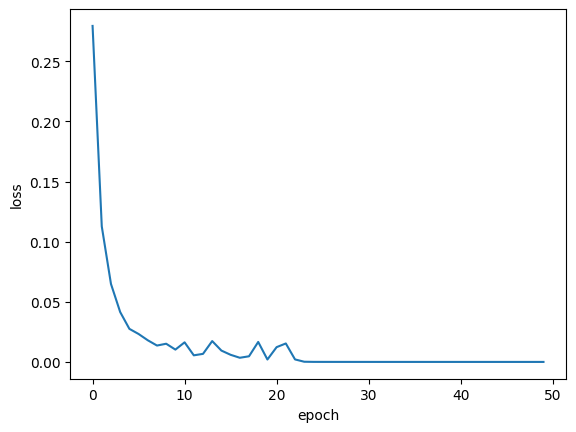

In [50]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

#정확도 곡선

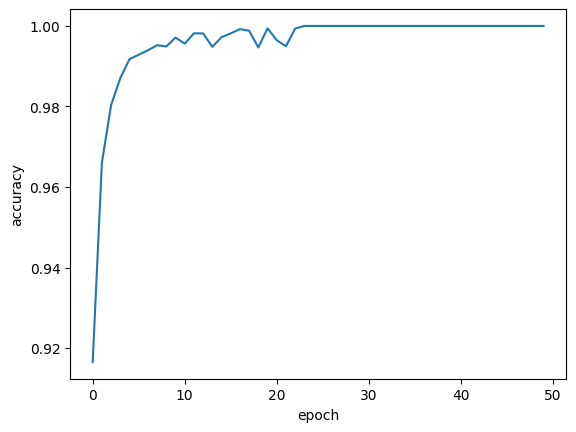

In [ ]:
import matplotlib.pyplot as plt
plt.plot(hist.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()#p값은 집어넣은다??
#적당한 범위 10=>earlystopping조기종료

#test_data로 predict 해보기

In [54]:
#수화 이미지 인식
pred=model.predict(test_data)
print('test_label:',test_label[:10])
print("pred:",pred[:10])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
test_label:    0
0  7
1  2
2  1
3  0
4  4
5  1
6  4
7  9
8  5
9  9
pred: [[2.3466253e-29 2.2730330e-27 2.1619286e-21 4.7087281e-18 1.2319466e-37
  4.6364630e-28 9.8420801e-37 1.0000000e+00 5.5748165e-27 9.9301182e-26]
 [1.9835158e-24 1.2585958e-13 1.0000000e+00 1.3897349e-15 0.0000000e+00
  8.8405837e-28 8.4980603e-25 9.8725680e-31 5.0137986e-23 8.7363313e-33]
 [4.4578747e-20 1.0000000e+00 4.8835105e-09 2.6231538e-17 3.6319502e-12
  5.5332338e-17 1.2849570e-14 9.9234976e-10 1.2127329e-12 7.1352021e-18]
 [1.0000000e+00 1.2897704e-28 3.2079793e-16 2.6348507e-22 5.5922697e-24
  1.3635678e-22 9.3129519e-17 1.0479769e-19 2.1112702e-26 7.2816438e-20]
 [8.1067487e-23 1.5929264e-29 2.9460535e-24 1.4305161e-24 1.0000000e+00
  6.6647832e-26 1.0025461e-18 1.0458054e-17 6.4976635e-19 5.2280732e-12]
 [8.9342645e-26 1.0000000e+00 6.1300404e-16 7.8087188e-22 4.4248484e-15
  9.8124397e-27 3.8674841e-22 2.0959354e-11 3.1937634e-18 2.2900616e-23]
 [7.1140537e-34 4

In [55]:
pred[:10]#출력층 10개#0인 확률?#뽑아와야함

array([[2.3466253e-29, 2.2730330e-27, 2.1619286e-21, 4.7087281e-18,
        1.2319466e-37, 4.6364630e-28, 9.8420801e-37, 1.0000000e+00,
        5.5748165e-27, 9.9301182e-26],
       [1.9835158e-24, 1.2585958e-13, 1.0000000e+00, 1.3897349e-15,
        0.0000000e+00, 8.8405837e-28, 8.4980603e-25, 9.8725680e-31,
        5.0137986e-23, 8.7363313e-33],
       [4.4578747e-20, 1.0000000e+00, 4.8835105e-09, 2.6231538e-17,
        3.6319502e-12, 5.5332338e-17, 1.2849570e-14, 9.9234976e-10,
        1.2127329e-12, 7.1352021e-18],
       [1.0000000e+00, 1.2897704e-28, 3.2079793e-16, 2.6348507e-22,
        5.5922697e-24, 1.3635678e-22, 9.3129519e-17, 1.0479769e-19,
        2.1112702e-26, 7.2816438e-20],
       [8.1067487e-23, 1.5929264e-29, 2.9460535e-24, 1.4305161e-24,
        1.0000000e+00, 6.6647832e-26, 1.0025461e-18, 1.0458054e-17,
        6.4976635e-19, 5.2280732e-12],
       [8.9342645e-26, 1.0000000e+00, 6.1300404e-16, 7.8087188e-22,
        4.4248484e-15, 9.8124397e-27, 3.8674841e-22, 2.09

In [ ]:
#np.argmax:가장 좋은 아이의 인덱스: 예측값의 최대값의 인덱스
np.argmax(pred[:10])#제일 처음값만 알려줌

np.int64(7)

In [ ]:
pred[:10]

In [ ]:
np.argmax(pred[:10],axis=1)#2차원 행과열#5=>6

array([7, 2, 1, 0, 4, 1, 4, 9, 6, 9])

#번외 :image만들기

In [ ]:
from PIL import Image#PIL

In [59]:
#증강admentation?
train.shape

(20001, 785)

In [ ]:
train1 = train.loc[:,train.columns!=0]
train1.shape#target data/정규화

(20001, 784)

In [61]:
abc=np.array(train1.iloc[50]).reshape(28,28)
abc.shape

(28, 28)

In [ ]:
abc#2차원 데이터

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  12,  56, 140,
        126, 175, 200,  96,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  35, 166, 238, 254, 246,
        242, 253, 246, 254,  67,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [ ]:
#Image 만들기(pil image<=>np) 8비트
image= Image.fromarray((abc).astype(np.uint8))
image#jpg:숫자

In [64]:
#image 저장하기
image.save("../Data/mnist_test_3.jpg","JPEG")

#이미지를 불러서 predict 해보기

In [66]:
#Image 불러오기
img = Image.open("../Data/mnist_test_3.jpg")
img

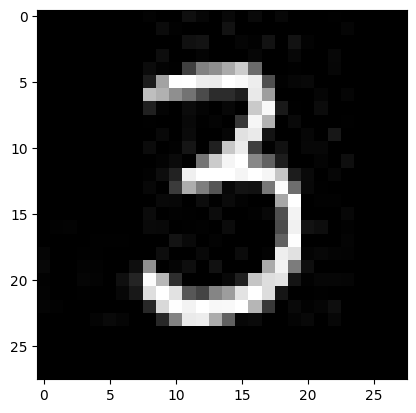

In [69]:
plt.imshow(img,cmap='gray')#jpg
plt.show()

In [ ]:
#array=>predict
#image를 numpy 배열로 변환
imgArray = np.array(img)
imgArray=imgArray/255#이미지=>숫자
imgArray.shape#학습후 원래대로 변환

(28, 28)

In [72]:
#imgArray를 1차원 배열로 변경하기
imgArray2= imgArray.reshape(-1)
imgArray2.shape

(784,)

In [ ]:
imgArray2#1차원 데이터

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.01176471, 0.        ,
       0.        , 0.05882353, 0.02352941, 0.        , 0.03137255,
       0.        , 0.03529412, 0.        , 0.02745098, 0.        ,
       0.        , 0.        , 0.00392157, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.04313725, 0.00784314, 0.        ,
       0.        , 0.        , 0.07058824, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.01960784, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.0627451 , 0.0745098 , 0.        ,
       0.        , 0.01960784, 0.00784314, 0.07058824, 0.     

In [78]:
imgArray3=imgArray2.tolist()
dfArray=pd.DataFrame(imgArray3)
dfArray=dfArray.T
dfArray

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011765,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [76]:
test_data#데이터 프레임

,1,2,3,4,5,6,7,8,9,10,...,775,776,777,778,779,780,781,782,783,784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
np.argmax(model.predict(dfArray), axis=1)#데이터 프레임으로 바꿔줘야함
#아이패드용 손글씨 인식 계산기#데이터 비교 기스났을때

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


array([3])